# VQA Quality Analysis with Multi-Model Validation
This notebook performs BERT-based semantic quality analysis of VQA datasets and validates findings through model inference experiments.

**Structure:**
- Part 1-17: Core BERT-based quality metrics
- Part 18-21 (NEW): Multi-model inference validation &amp; downstream task analysis

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================================
# Part 1: Install and Import Dependencies
# ============================================================================
import subprocess
import sys

def install_if_needed(package, import_name=None):
    """Install package if not available"""
    import_name = import_name or package
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# Install required packages
install_if_needed("sentence-transformers", "sentence_transformers")
install_if_needed("pandas")
install_if_needed("numpy")
install_if_needed("matplotlib")
install_if_needed("seaborn")
install_if_needed("scipy")

print("✅ All dependencies installed")

✅ All dependencies installed


In [7]:
# ============================================================================
# Part 2: Import Libraries
# ============================================================================
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [8]:
# ============================================================================
# Part 3: Load BERT Model (Using lightweight all-MiniLM-L6-v2 for speed)
# ============================================================================
print("Loading Sentence-BERT model...")
print("Using 'all-MiniLM-L6-v2' - fast and efficient (80MB, 5x faster than BERT-base)")

# all-MiniLM-L6-v2 is optimized for semantic similarity tasks
# It's ~5x faster than BERT-base while maintaining good quality
model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"✅ Model loaded: {model.get_sentence_embedding_dimension()}-dim embeddings")

Loading Sentence-BERT model...
Using 'all-MiniLM-L6-v2' - fast and efficient (80MB, 5x faster than BERT-base)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded: 384-dim embeddings


In [9]:
# ============================================================================
# Part 4: Define Data Paths
# ============================================================================
# DATA_DIR = Path("/home/24068286g/UString/VRU/src/option_generate/data")
from pathlib import Path
# Three versions of VQA datasets
csv_files = {
    "2_options": '/content/drive/MyDrive/data/MultiChoice/generated_options_2opts_20260327_085451.csv',
    "3_options": '/content/drive/MyDrive/data/MultiChoice/generated_options_3opts_20260327_085451.csv',
    "4_options": '/content/drive/MyDrive/data/MultiChoice/generated_options_4opts_20260327_085451.csv',
    "5_options": '/content/drive/MyDrive/data/MultiChoice/generated_options_5opts_20260327_085451.csv'
}
csv_files = {name: Path(path) for name, path in csv_files.items()}
# # Check file existence
for name, path in csv_files.items():
    status = "✅" if path.exists() else "❌"
    print(f"{status} {name}: {path.name}")

✅ 2_options: generated_options_2opts_20260327_085451.csv
✅ 3_options: generated_options_3opts_20260327_085451.csv
✅ 4_options: generated_options_4opts_20260327_085451.csv
✅ 5_options: generated_options_5opts_20260327_085451.csv


In [10]:
# ============================================================================
# Part 5: Load and Parse CSV Data
# ============================================================================
def load_qa_data(csv_path: Path, num_options: int) -> pd.DataFrame:
    """
    Load QA data from CSV and extract questions with their options.

    IMPORTANT: Data structure is ONE ROW = ONE QUESTION, with columns:
    - question, correct_answer, option_1, option_2, ..., option_N

    Returns DataFrame with columns:
    - video_id, q_id, question, correct_answer, wrong_options (list)
    """
    # Try multiple encodings
    df = None
    for encoding in ['utf-8', 'gbk', 'gb2312', 'latin-1']:
        try:
            df = pd.read_csv(csv_path, encoding=encoding)
            break
        except (UnicodeDecodeError, LookupError) as e:
            if encoding == 'latin-1':
                raise Exception(f"Failed to decode {csv_path} with all attempted encodings: {e}")
            continue

    if df is None:
        raise Exception(f"Failed to load {csv_path}")

    # Support both historical and new schema names
    if 'video_id' in df.columns:
        video_col = 'video_id'
    elif 'video_number' in df.columns:
        video_col = 'video_number'
    else:
        raise KeyError(f"Neither 'video_id' nor 'video_number' exists in {csv_path}")

    records = []
    skipped_no_question = 0
    skipped_no_correct = 0
    skipped_no_wrong = 0

    for _, row in df.iterrows():
        # Get question
        question = row.get('question', '')
        if pd.isna(question) or not str(question).strip():
            skipped_no_question += 1
            continue

        # Get correct answer
        correct_answer = row.get('correct_answer', '')
        if pd.isna(correct_answer) or not str(correct_answer).strip():
            skipped_no_correct += 1
            continue

        # Collect wrong options (option_1, option_2, ..., option_N)
        wrong_options = []
        for opt_idx in range(1, num_options):  # num_options-1 wrong answers
            opt_col = f'option_{opt_idx}'
            if opt_col in df.columns:
                opt_val = row.get(opt_col, '')
                if not pd.isna(opt_val) and str(opt_val).strip():
                    wrong_options.append(str(opt_val).strip())

        if wrong_options:
            records.append({
                'video_id': row.get(video_col, None),
                'q_id': row.get('question_id', None),
                'question': str(question).strip(),
                'correct_answer': str(correct_answer).strip(),
                'wrong_options': wrong_options,
                'num_options': len(wrong_options) + 1  # Total options including correct
            })
        else:
            skipped_no_wrong += 1

    print(
        f"[{csv_path.name}] raw_rows={len(df)}, parsed_questions={len(records)}, "
        f"skipped(no_question)={skipped_no_question}, "
        f"skipped(no_correct)={skipped_no_correct}, "
        f"skipped(no_wrong)={skipped_no_wrong}, "
        f"id_col={video_col}"
    )

    return pd.DataFrame(records)

# Load all datasets
datasets = {}
for name, path in csv_files.items():
    if path.exists():
        num_opts = int(name.split('_')[0])

        datasets[name] = load_qa_data(path, num_opts)
        print(f"📊 {name}: {len(datasets[name])} questions loaded")

print(f"\n✅ Total datasets loaded: {len(datasets)}")


[generated_options_2opts_20260327_085451.csv] raw_rows=1194, parsed_questions=1194, skipped(no_question)=0, skipped(no_correct)=0, skipped(no_wrong)=0, id_col=video_id
📊 2_options: 1194 questions loaded
[generated_options_3opts_20260327_085451.csv] raw_rows=1194, parsed_questions=1194, skipped(no_question)=0, skipped(no_correct)=0, skipped(no_wrong)=0, id_col=video_id
📊 3_options: 1194 questions loaded
[generated_options_4opts_20260327_085451.csv] raw_rows=1194, parsed_questions=1194, skipped(no_question)=0, skipped(no_correct)=0, skipped(no_wrong)=0, id_col=video_id
📊 4_options: 1194 questions loaded
[generated_options_5opts_20260327_085451.csv] raw_rows=1194, parsed_questions=1194, skipped(no_question)=0, skipped(no_correct)=0, skipped(no_wrong)=0, id_col=video_id
📊 5_options: 1194 questions loaded

✅ Total datasets loaded: 4


In [ ]:
# ============================================================================
# Part 6: BERT-based Similarity Functions
# ============================================================================
def compute_bert_similarity(text1: str, text2: str) -> float:
    """
    Compute cosine similarity between two texts using BERT embeddings.
    Returns value in [0, 1] where 1 means identical.
    """
    embeddings = model.encode([text1, text2], convert_to_numpy=True)
    similarity = 1 - cosine(embeddings[0], embeddings[1])
    return max(0, similarity)  # Ensure non-negative

def compute_batch_embeddings(texts: List[str]) -> np.ndarray:
    """Compute embeddings for a batch of texts (much faster)"""
    return model.encode(texts, convert_to_numpy=True, show_progress_bar=False)

def cosine_similarity_matrix(embeddings: np.ndarray) -> np.ndarray:
    """Compute pairwise cosine similarity matrix"""
    # Normalize embeddings
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms
    # Compute similarity matrix
    return np.dot(normalized, normalized.T)

# Test the functions
test_sim = compute_bert_similarity(
    "The car crashed into the pedestrian",
    "A vehicle hit a person walking"
)
print(f"Test similarity (semantically similar texts): {test_sim:.4f}")

test_sim2 = compute_bert_similarity(
    "The car crashed into the pedestrian",
    "The weather is sunny today"
)
print(f"Test similarity (unrelated texts): {test_sim2:.4f}")

Test similarity (semantically similar texts): 0.5902
Test similarity (unrelated texts): 0.0252


### Quality Metrics Computation

In [ ]:
# Part 10: Process Directory

import os

def process_directory(directory_path: str, model_name: str = 'all-MiniLM-L6-v2') -> Dict[str, Dict]:
    """
    Process all JSON files in a directory and calculate quality metrics.
    """
    results_by_options = {}
    
    # Process files
    for filename in os.listdir(directory_path):
        if not filename.endswith('.json'):
            continue
            
        file_path = os.path.join(directory_path, filename)
        try:
            # Extract number of options from filename (e.g., '3_options' -> 3)
            # You might need to adjust this depending on your exact filename format
            import re
            match = re.search(r'(\d+)_options', filename)
            if match:
                num_options = int(match.group(1))
            else:
                num_options = "unknown_" + filename
                
            print(f"\nProcessing {filename}...")
            analyzer = MultipleChoiceAnalyzer(model_name)
            metrics = analyzer.evaluate_dataset(file_path)
            results_by_options[str(num_options)] = metrics
            
        except Exception as e:
            print(f"Error processing {filename}: {e}")
            
    return results_by_options

In [13]:
# ============================================================================
# Part 8: Batch Analysis for All Datasets
# ============================================================================
from tqdm import tqdm

def analyze_dataset(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Analyze all questions in a dataset and return metrics DataFrame.
    """
    print(f"\n🔄 Analyzing {name} ({len(df)} questions)...")

    results = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {name}"):
        try:
            metrics = analyze_question_quality(row)
            metrics['question_idx_orig'] = int(idx)
            metrics['video_id'] = row.get('video_id', row.get('video_number', None))
            metrics['q_id'] = row['q_id']
            metrics['num_options'] = row['num_options']
            metrics['dataset'] = name
            results.append(metrics)
        except Exception as e:
            print(f"Error processing row {idx}: {e}")
            continue

    return pd.DataFrame(results)

# Analyze all datasets
all_results = []
for name, df in datasets.items():
    result_df = analyze_dataset(df, name)
    all_results.append(result_df)
    print(f"✅ {name}: {len(result_df)} questions analyzed")

# Combine all results
combined_results = pd.concat(all_results, ignore_index=True)
print(f"\n📊 Total analyzed: {len(combined_results)} question instances")


🔄 Analyzing 2_options (1194 questions)...


Processing 2_options: 100%|██████████| 1194/1194 [01:16<00:00, 15.54it/s]


✅ 2_options: 1194 questions analyzed

🔄 Analyzing 3_options (1194 questions)...


Processing 3_options: 100%|██████████| 1194/1194 [01:22<00:00, 14.54it/s]


✅ 3_options: 1194 questions analyzed

🔄 Analyzing 4_options (1194 questions)...


Processing 4_options: 100%|██████████| 1194/1194 [01:32<00:00, 12.96it/s]


✅ 4_options: 1194 questions analyzed

🔄 Analyzing 5_options (1194 questions)...


Processing 5_options: 100%|██████████| 1194/1194 [01:44<00:00, 11.47it/s]

✅ 5_options: 1194 questions analyzed

📊 Total analyzed: 4776 question instances


In [14]:
# ============================================================================
# Part 9: Statistical Comparison
# ============================================================================
def compute_statistics(combined_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute summary statistics for each dataset version.
    """
    metrics = ['option_diversity', 'distractor_quality', 'question_relevance',
               'separability', 'avg_distractor_similarity']

    stats_data = []

    for dataset_name in combined_df['dataset'].unique():
        subset = combined_df[combined_df['dataset'] == dataset_name]

        row = {'dataset': dataset_name}
        for metric in metrics:
            values = subset[metric]
            row[f'{metric}_mean'] = values.mean()
            row[f'{metric}_std'] = values.std()
            row[f'{metric}_median'] = values.median()

        row['count'] = len(subset)
        stats_data.append(row)

    return pd.DataFrame(stats_data)

summary_stats = compute_statistics(combined_results)

print("\n" + "="*80)
print("📊 BERT-based Quality Analysis Summary")
print("="*80)

# Display key metrics
display_cols = ['dataset', 'count',
                'option_diversity_mean', 'distractor_quality_mean',
                'question_relevance_mean', 'separability_mean']

print("\n📈 Mean Quality Scores by Dataset:")
print(summary_stats[display_cols].to_string(index=False))


📊 BERT-based Quality Analysis Summary

📈 Mean Quality Scores by Dataset:
  dataset  count  option_diversity_mean  distractor_quality_mean  question_relevance_mean  separability_mean
2_options   1194               0.500000                 0.528382                 0.413170           0.297304
3_options   1194               0.388197                 0.565958                 0.415497           0.256444
4_options   1194               0.404515                 0.597774                 0.418155           0.238997
5_options   1194               0.423325                 0.638147                 0.418404           0.233915


In [15]:
# ============================================================================
# Part 10: Statistical Significance Tests
# ============================================================================
def perform_statistical_tests(combined_df: pd.DataFrame) -> Dict:
    """
    Perform statistical tests to compare dataset versions.
    Uses Kruskal-Wallis H-test (non-parametric) and pairwise Mann-Whitney U tests.
    """
    metrics = ['option_diversity', 'distractor_quality', 'question_relevance', 'separability']
    datasets_list = sorted(combined_df['dataset'].unique())

    results = {}

    for metric in metrics:
        print(f"\n{'='*60}")
        print(f"📊 Statistical Tests for: {metric}")
        print(f"{'='*60}")

        # Prepare data groups
        groups = [combined_df[combined_df['dataset'] == d][metric].values for d in datasets_list]

        # Kruskal-Wallis H-test (non-parametric ANOVA)
        h_stat, p_value = stats.kruskal(*groups)
        print(f"\nKruskal-Wallis H-test:")
        print(f"  H-statistic: {h_stat:.4f}")
        print(f"  p-value: {p_value:.6f}")
        print(f"  Significant (p<0.05): {'✅ YES' if p_value < 0.05 else '❌ NO'}")

        # Pairwise Mann-Whitney U tests
        print(f"\nPairwise Mann-Whitney U tests:")
        pairwise_results = {}
        for i, d1 in enumerate(datasets_list):
            for j, d2 in enumerate(datasets_list):
                if i < j:
                    g1 = combined_df[combined_df['dataset'] == d1][metric].values
                    g2 = combined_df[combined_df['dataset'] == d2][metric].values
                    u_stat, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')

                    # Effect size (rank-biserial correlation)
                    n1, n2 = len(g1), len(g2)
                    effect_size = 1 - (2*u_stat)/(n1*n2)

                    sig = '✅' if p_val < 0.05 else ''
                    print(f"  {d1} vs {d2}: U={u_stat:.0f}, p={p_val:.4f} {sig}, effect={effect_size:.3f}")
                    pairwise_results[f"{d1}_vs_{d2}"] = {
                        'u_statistic': u_stat,
                        'p_value': p_val,
                        'effect_size': effect_size,
                        'significant': p_val < 0.05
                    }

        results[metric] = {
            'kruskal_wallis': {'h_statistic': h_stat, 'p_value': p_value},
            'pairwise': pairwise_results
        }

    return results

stat_test_results = perform_statistical_tests(combined_results)


📊 Statistical Tests for: option_diversity

Kruskal-Wallis H-test:
  H-statistic: 796.1622
  p-value: 0.000000
  Significant (p<0.05): ✅ YES

Pairwise Mann-Whitney U tests:
  2_options vs 3_options: U=1108032, p=0.0000 ✅, effect=-0.554
  2_options vs 4_options: U=1110420, p=0.0000 ✅, effect=-0.558
  2_options vs 5_options: U=1047138, p=0.0000 ✅, effect=-0.469
  3_options vs 4_options: U=656858, p=0.0009 ✅, effect=0.079
  3_options vs 5_options: U=598056, p=0.0000 ✅, effect=0.161
  4_options vs 5_options: U=649509, p=0.0002 ✅, effect=0.089

📊 Statistical Tests for: distractor_quality

Kruskal-Wallis H-test:
  H-statistic: 178.7482
  p-value: 0.000000
  Significant (p<0.05): ✅ YES

Pairwise Mann-Whitney U tests:
  2_options vs 3_options: U=641526, p=0.0000 ✅, effect=0.100
  2_options vs 4_options: U=576132, p=0.0000 ✅, effect=0.192
  2_options vs 5_options: U=501584, p=0.0000 ✅, effect=0.296
  3_options vs 4_options: U=645781, p=0.0001 ✅, effect=0.094
  3_options vs 5_options: U=566457, 


✅ Figure saved: /content/drive/MyDrive/data/BERT_analysis2/bert_quality_analysis_boxplot.png


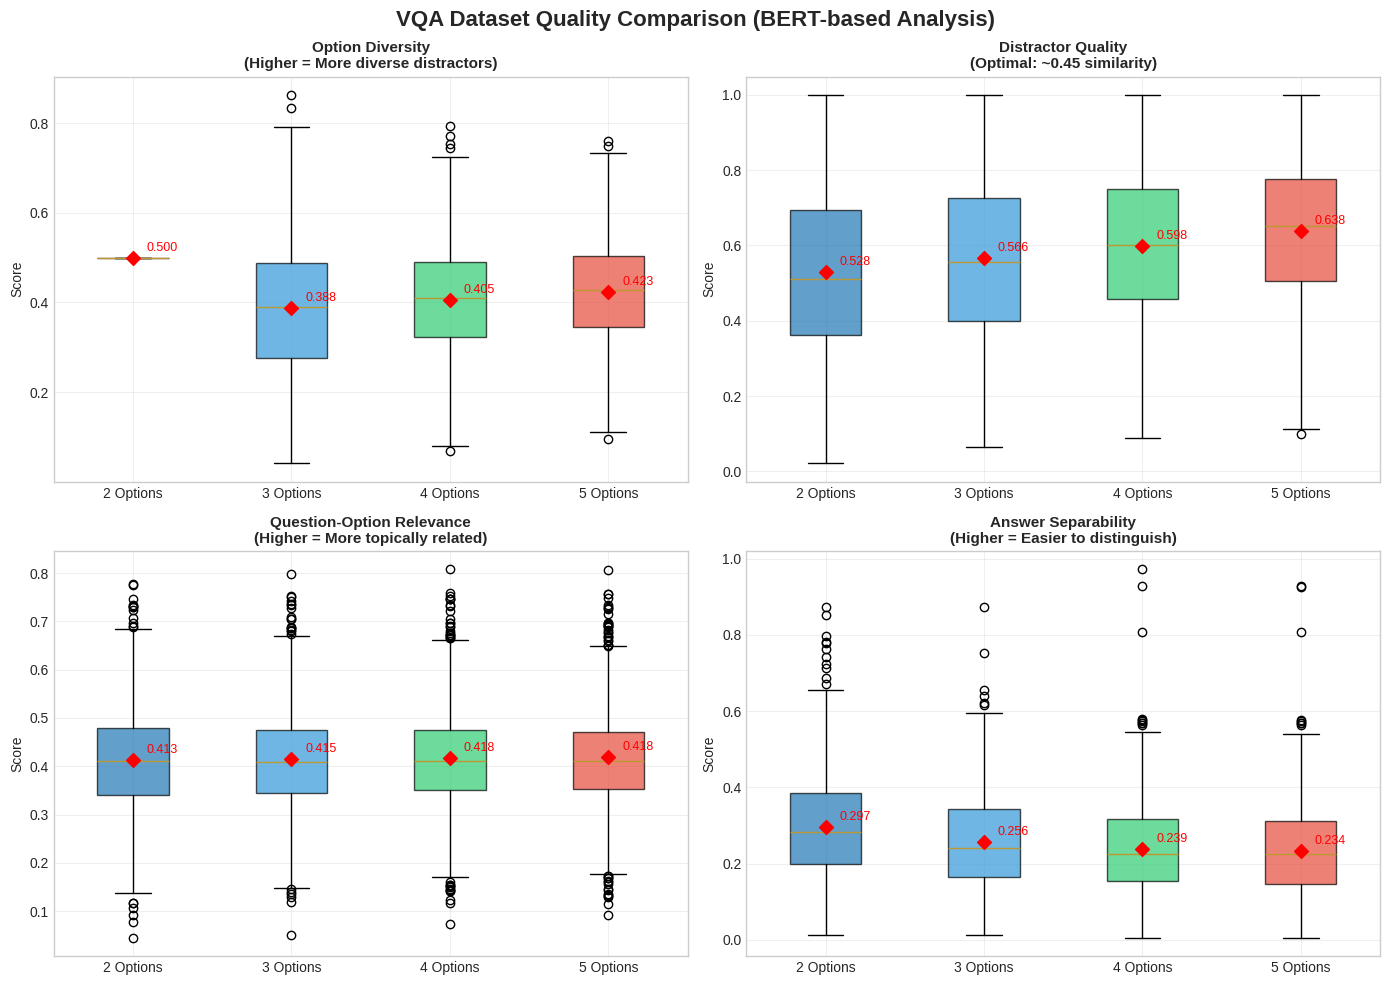

In [16]:
# ============================================================================
# Part 11: Visualization - Box Plots
# ============================================================================
def plot_quality_comparison(combined_df: pd.DataFrame):
    """
    Create comprehensive visualization of quality metrics.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('VQA Dataset Quality Comparison (BERT-based Analysis)',
                 fontsize=16, fontweight='bold')

    metrics = [
        ('option_diversity', 'Option Diversity\n(Higher = More diverse distractors)', axes[0, 0]),
        ('distractor_quality', 'Distractor Quality\n(Optimal: ~0.45 similarity)', axes[0, 1]),
        ('question_relevance', 'Question-Option Relevance\n(Higher = More topically related)', axes[1, 0]),
        ('separability', 'Answer Separability\n(Higher = Easier to distinguish)', axes[1, 1])
    ]

    # Update colors to include '2_options'
    colors_map = {'2_options': '#1f77b4', '3_options': '#3498db', '4_options': '#2ecc71', '5_options': '#e74c3c'}
    sorted_datasets = sorted(combined_df['dataset'].unique())

    for metric, title, ax in metrics:
        # Box plot
        bp = ax.boxplot(
            [combined_df[combined_df['dataset'] == d][metric].values
             for d in sorted_datasets],
            labels=[f'{d.split("_")[0]} Options' for d in sorted_datasets],
            patch_artist=True
        )

        # Color the boxes
        for patch, dataset_name in zip(bp['boxes'], sorted_datasets):
            patch.set_facecolor(colors_map[dataset_name])
            patch.set_alpha(0.7)

        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel('Score', fontsize=10)
        ax.grid(True, alpha=0.3)

        # Add mean markers
        means = [combined_df[combined_df['dataset'] == d][metric].mean()
                 for d in sorted_datasets]
        # Adjust x-coordinates for scatter to match number of datasets
        x_coords = np.arange(1, len(sorted_datasets) + 1)
        ax.scatter(x_coords, means, color='red', marker='D', s=50, zorder=3, label='Mean')

        # Add mean values as text
        for i, m in enumerate(means):
            ax.annotate(f'{m:.3f}', (x_coords[i], m), textcoords="offset points",
                       xytext=(10, 5), fontsize=9, color='red')

    plt.tight_layout()

    # Save figure
    output_path = '/content/drive/MyDrive/data/BERT_analysis2/bert_quality_analysis_boxplot.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✅ Figure saved: {output_path}")

    plt.show()

plot_quality_comparison(combined_results)



✅ Figure saved: /content/drive/MyDrive/data/BERT_analysis2/bert_quality_analysis_kde.png


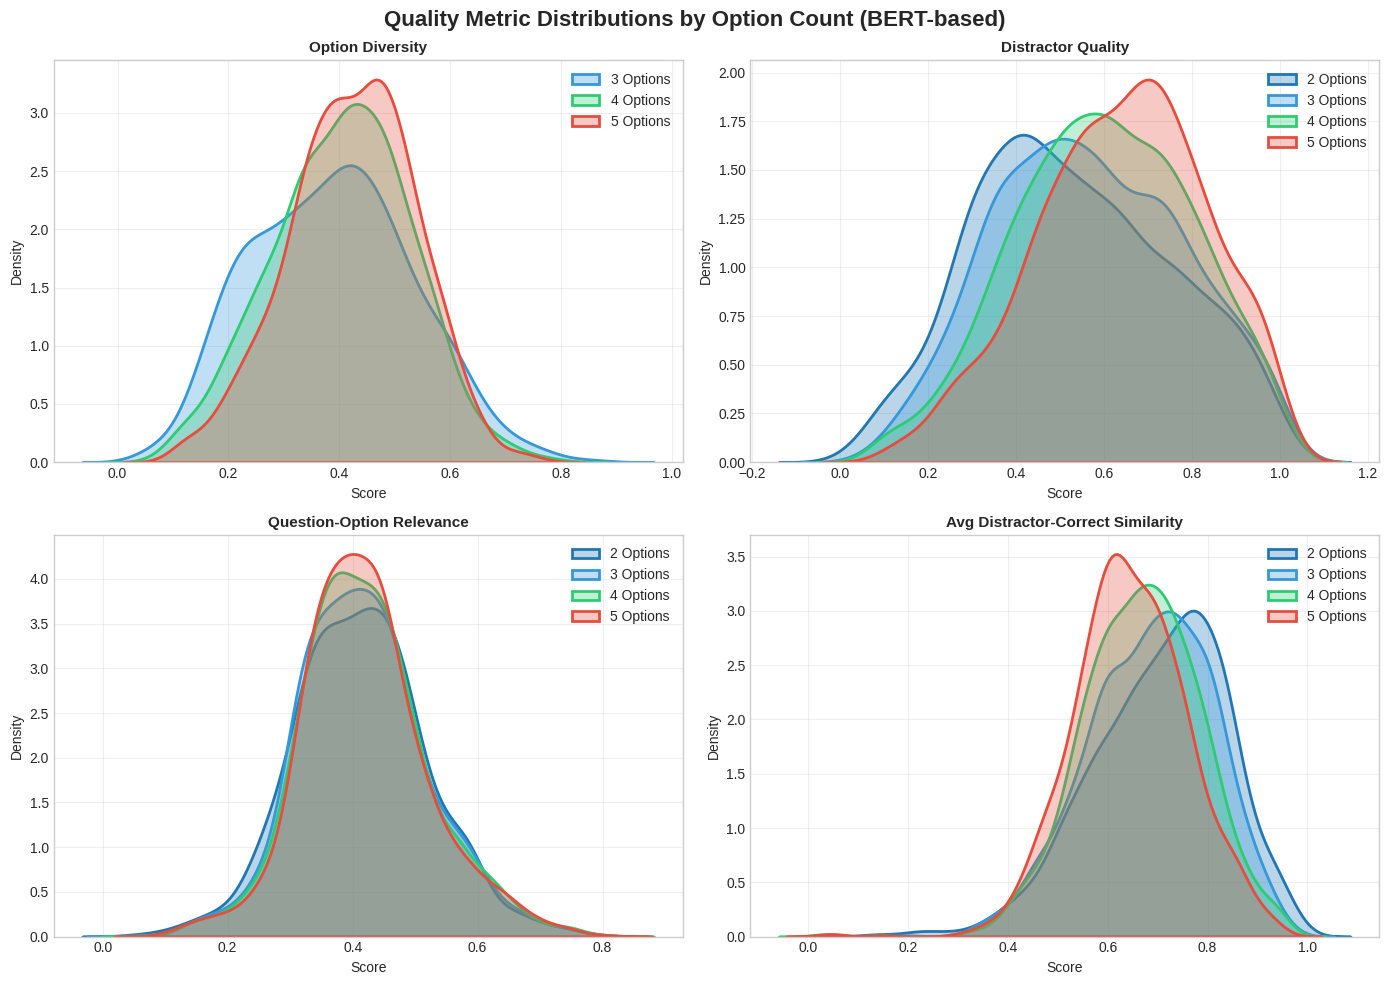

In [17]:
# ============================================================================
# Part 12: Visualization - Distribution Plots
# ============================================================================
def plot_distributions(combined_df: pd.DataFrame):
    """
    Plot kernel density estimates for each metric.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Quality Metric Distributions by Option Count (BERT-based)',
                 fontsize=16, fontweight='bold')

    metrics = [
        ('option_diversity', 'Option Diversity', axes[0, 0]),
        ('distractor_quality', 'Distractor Quality', axes[0, 1]),
        ('question_relevance', 'Question-Option Relevance', axes[1, 0]),
        ('avg_distractor_similarity', 'Avg Distractor-Correct Similarity', axes[1, 1])
    ]

    # Update colors and labels to include '2_options'
    colors_map = {'2_options': '#1f77b4', '3_options': '#3498db', '4_options': '#2ecc71', '5_options': '#e74c3c'}
    labels_map = {'2_options': '2 Options', '3_options': '3 Options', '4_options': '4 Options', '5_options': '5 Options'}

    for metric, title, ax in metrics:
        for dataset_name in sorted(combined_df['dataset'].unique()):
            data = combined_df[combined_df['dataset'] == dataset_name][metric]
            sns.kdeplot(data, ax=ax, label=labels_map[dataset_name],
                       color=colors_map[dataset_name], linewidth=2, fill=True, alpha=0.3)

        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Score', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save figure
    output_path = "/content/drive/MyDrive/data/BERT_analysis2/bert_quality_analysis_kde.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✅ Figure saved: {output_path}")

    plt.show()

plot_distributions(combined_results)


✅ Figure saved: /content/drive/MyDrive/data/BERT_analysis2/bert_quality_analysis_radar.png


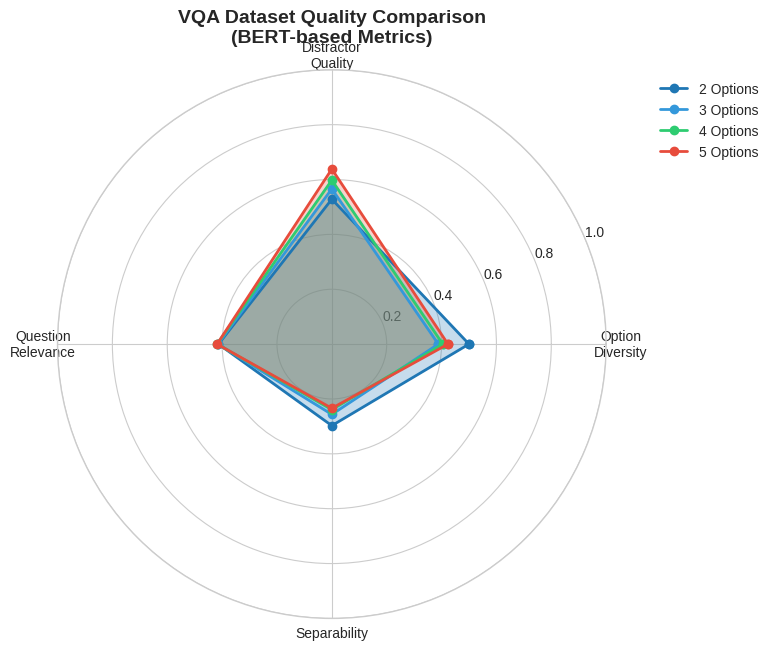

In [18]:
# ============================================================================
# Part 13: Radar Chart Comparison
# ============================================================================
def plot_radar_comparison(summary_df: pd.DataFrame):
    """
    Create radar chart comparing all datasets across metrics.
    """
    metrics = ['option_diversity_mean', 'distractor_quality_mean',
               'question_relevance_mean', 'separability_mean']
    metric_labels = ['Option\nDiversity', 'Distractor\nQuality',
                    'Question\nRelevance', 'Separability']

    # Number of metrics
    N = len(metrics)

    # Compute angle for each metric
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Update colors and labels to include '2_options'
    colors_map = {'2_options': '#1f77b4', '3_options': '#3498db', '4_options': '#2ecc71', '5_options': '#e74c3c'}
    labels_map = {'2_options': '2 Options', '3_options': '3 Options', '4_options': '4 Options', '5_options': '5 Options'}

    for _, row in summary_df.iterrows():
        dataset = row['dataset']
        # Ensure we only plot datasets present in the maps
        if dataset in colors_map and dataset in labels_map:
            values = [row[m] for m in metrics]
            values += values[:1]  # Complete the loop

            ax.plot(angles, values, 'o-', linewidth=2, label=labels_map[dataset],
                    color=colors_map[dataset])
            ax.fill(angles, values, alpha=0.25, color=colors_map[dataset])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title('VQA Dataset Quality Comparison\n(BERT-based Metrics)',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)

    plt.tight_layout()

    # Save figure
    output_path = "/content/drive/MyDrive/data/BERT_analysis2/bert_quality_analysis_radar.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✅ Figure saved: {output_path}")

    plt.show()

plot_radar_comparison(summary_stats)

In [19]:
# ============================================================================
# Part 14: Composite Quality Score
# ============================================================================
def compute_composite_score(combined_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute a composite quality score combining all metrics.

    Weights:
    - Option Diversity: 0.25 (important for challenging distractors)
    - Distractor Quality: 0.30 (most important - right difficulty level)
    - Question Relevance: 0.20 (options should be topically relevant)
    - Separability: 0.25 (correct answer should be distinguishable)
    """
    weights = {
        'option_diversity': 0.25,
        'distractor_quality': 0.30,
        'question_relevance': 0.20,
        'separability': 0.25
    }

    combined_df['composite_score'] = (
        combined_df['option_diversity'] * weights['option_diversity'] +
        combined_df['distractor_quality'] * weights['distractor_quality'] +
        combined_df['question_relevance'] * weights['question_relevance'] +
        combined_df['separability'] * weights['separability']
    )

    return combined_df

combined_results = compute_composite_score(combined_results)

# Summary by dataset
print("\n" + "="*80)
print("📊 COMPOSITE QUALITY SCORE SUMMARY")
print("="*80)
print("\nWeights: Diversity=0.25, Distractor Quality=0.30, Relevance=0.20, Separability=0.25")
print("\n")

composite_summary = combined_results.groupby('dataset')['composite_score'].agg(['mean', 'std', 'median'])
composite_summary = composite_summary.round(4)
print(composite_summary)

# Best dataset
best_dataset = composite_summary['mean'].idxmax()
print(f"\n🏆 Best Overall Quality: {best_dataset} (mean composite score: {composite_summary.loc[best_dataset, 'mean']:.4f})")


📊 COMPOSITE QUALITY SCORE SUMMARY

Weights: Diversity=0.25, Distractor Quality=0.30, Relevance=0.20, Separability=0.25


             mean     std  median
dataset                          
2_options  0.4405  0.0953  0.4313
3_options  0.4140  0.1152  0.4077
4_options  0.4238  0.1055  0.4240
5_options  0.4394  0.1003  0.4436

🏆 Best Overall Quality: 2_options (mean composite score: 0.4405)



✅ Figure saved: /content/drive/MyDrive/data/BERT_analysis2/bert_quality_analysis_final.png


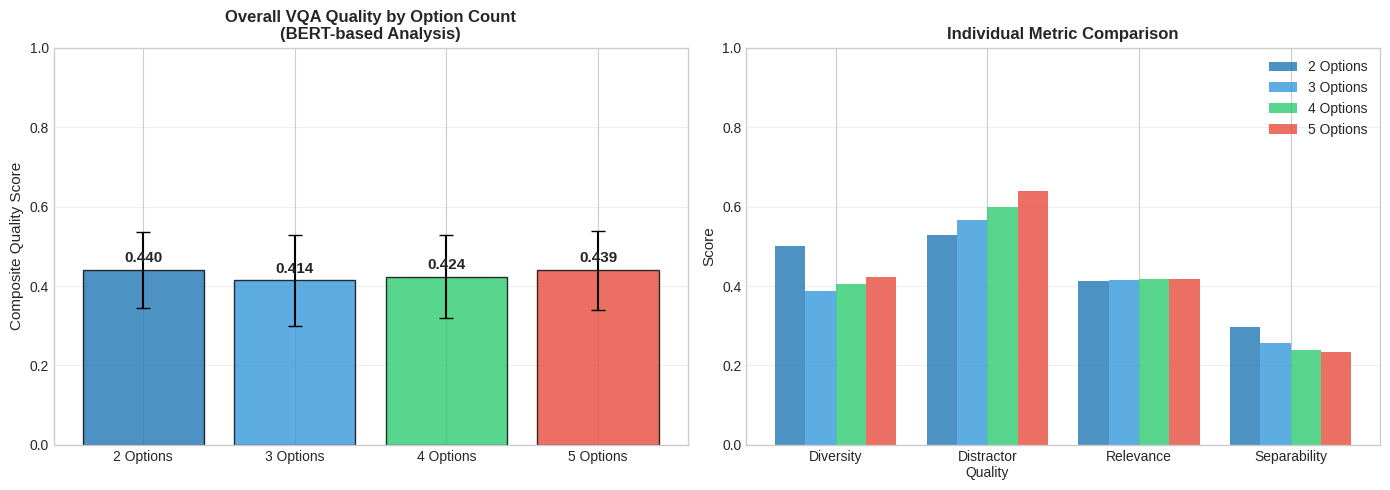

In [20]:
# ============================================================================
# Part 15: Final Comparison Bar Chart
# ============================================================================
def plot_final_comparison(combined_df: pd.DataFrame, summary_df: pd.DataFrame):
    """
    Create final comparison bar chart with composite scores.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Composite score comparison
    ax = axes[0]
    composite_means = combined_df.groupby('dataset')['composite_score'].mean().sort_index()
    composite_stds = combined_df.groupby('dataset')['composite_score'].std().sort_index()

    # Dynamically get colors and labels based on available datasets
    sorted_datasets = composite_means.index.tolist()
    colors_map = {'2_options': '#1f77b4', '3_options': '#3498db', '4_options': '#2ecc71', '5_options': '#e74c3c'}
    plot_colors = [colors_map[d] for d in sorted_datasets]
    x_labels = [f'{d.split("_")[0]} Options' for d in sorted_datasets]

    bars = ax.bar(x_labels, composite_means.values, yerr=composite_stds.values,
                  color=plot_colors, alpha=0.8, capsize=5, edgecolor='black')

    ax.set_ylabel('Composite Quality Score', fontsize=11)
    ax.set_title('Overall VQA Quality by Option Count\n(BERT-based Analysis)',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, val in zip(bars, composite_means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

    # Right: Individual metrics comparison
    ax = axes[1]
    metrics = ['option_diversity_mean', 'distractor_quality_mean',
               'question_relevance_mean', 'separability_mean']
    metric_short = ['Diversity', 'Distractor\nQuality', 'Relevance', 'Separability']

    x = np.arange(len(metrics))
    width = 0.20 # Adjusted width for 4 bars

    for i, dataset in enumerate(sorted_datasets): # Iterate through sorted_datasets
        row = summary_df[summary_df['dataset'] == dataset].iloc[0]
        values = [row[m] for m in metrics]
        ax.bar(x + (i - (len(sorted_datasets) - 1) / 2) * width, values, width, label=f'{dataset.split("_")[0]} Options',
               color=colors_map[dataset], alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_short, fontsize=10)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Individual Metric Comparison', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1)

    plt.tight_layout()

    # Save figure
    output_path = "/content/drive/MyDrive/data/BERT_analysis2/bert_quality_analysis_final.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✅ Figure saved: {output_path}")

    plt.show()

plot_final_comparison(combined_results, summary_stats)

In [21]:
from datetime import datetime
from pathlib import Path

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

DATA_DIR = Path('/content/drive/MyDrive/data/BERT_analysis2')
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save detailed results
detail_path = DATA_DIR / f"bert_analysis_detailed_{timestamp}.csv"
combined_results.to_csv(detail_path, index=False)
print(f"✅ Detailed results saved: {detail_path}")

# Save summary statistics
summary_path = DATA_DIR / f"bert_analysis_summary_{timestamp}.csv"
summary_stats.to_csv(summary_path, index=False)
print(f"✅ Summary statistics saved: {summary_path}")

# Create a comprehensive report
report_path = DATA_DIR / f"bert_analysis_report_{timestamp}.txt"
with open(report_path, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("VQA Dataset Quality Analysis Report (BERT-based)\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("## Method\n")
    f.write("Using Sentence-BERT (all-MiniLM-L6-v2) for semantic similarity analysis.\n")
    f.write("This provides deeper semantic understanding compared to TF-IDF.\n\n")

    f.write("## Metrics Explained\n")
    f.write("1. Option Diversity: Semantic variety among wrong options (higher = better)\n")
    f.write("2. Distractor Quality: Optimal similarity to correct answer (~0.45 is ideal)\n")
    f.write("3. Question Relevance: How topically related options are to the question\n")
    f.write("4. Separability: How distinguishable the correct answer is\n\n")

    f.write("## Summary Statistics\n")
    f.write(summary_stats.to_string() + "\n\n")

    f.write("## Composite Score Rankings\n")
    composite_summary = combined_results.groupby('dataset')['composite_score'].agg(['mean', 'std'])
    f.write(composite_summary.sort_values('mean', ascending=False).to_string() + "\n\n")

    f.write("## Conclusion\n")
    best = composite_summary['mean'].idxmax()
    f.write(f"Based on BERT-based semantic analysis, '{best}' shows the best overall quality.\n")

print(f"✅ Report saved: {report_path}")

✅ Detailed results saved: /content/drive/MyDrive/data/BERT_analysis2/bert_analysis_detailed_20260329_150555.csv
✅ Summary statistics saved: /content/drive/MyDrive/data/BERT_analysis2/bert_analysis_summary_20260329_150555.csv
✅ Report saved: /content/drive/MyDrive/data/BERT_analysis2/bert_analysis_report_20260329_150555.txt


In [22]:
# ============================================================================
# Part 17: Summary and Conclusions
# ============================================================================
print("\n" + "="*80)
print("📋 ANALYSIS COMPLETE - BERT-based VQA Quality Assessment")
print("="*80)

print("\n📊 Key Findings:")
print("-" * 40)

# Find best for each metric
for metric in ['option_diversity_mean', 'distractor_quality_mean',
               'question_relevance_mean', 'separability_mean']:
    best = summary_stats.loc[summary_stats[metric].idxmax(), 'dataset']
    value = summary_stats[metric].max()
    metric_name = metric.replace('_mean', '').replace('_', ' ').title()
    print(f"• Best {metric_name}: {best} ({value:.4f})")

print("\n🏆 Overall Quality Ranking (Composite Score):")
print("-" * 40)
composite_ranking = combined_results.groupby('dataset')['composite_score'].mean().sort_values(ascending=False)
for i, (dataset, score) in enumerate(composite_ranking.items(), 1):
    medal = ['🥇', '🥈', '🥉'][i-1] if i <= 3 else f'{i}.'
    print(f"{medal} {dataset}: {score:.4f}")

print("\n💡 Interpretation:")
print("-" * 40)
print("• Higher option diversity = more challenging distractors")
print("• Optimal distractor quality (0.45) = similar enough to be confusing, different enough to be wrong")
print("• Higher question relevance = options are on-topic")
print("• Higher separability = correct answer is more distinguishable")

print("\n✅ BERT-based analysis provides deeper semantic understanding than TF-IDF")
print("   by capturing contextual meaning and handling synonyms/paraphrases better.")


📋 ANALYSIS COMPLETE - BERT-based VQA Quality Assessment

📊 Key Findings:
----------------------------------------
• Best Option Diversity: 2_options (0.5000)
• Best Distractor Quality: 5_options (0.6381)
• Best Question Relevance: 5_options (0.4184)
• Best Separability: 2_options (0.2973)

🏆 Overall Quality Ranking (Composite Score):
----------------------------------------
🥇 2_options: 0.4405
🥈 5_options: 0.4394
🥉 4_options: 0.4238
4. 3_options: 0.4140

💡 Interpretation:
----------------------------------------
• Higher option diversity = more challenging distractors
• Optimal distractor quality (0.45) = similar enough to be confusing, different enough to be wrong
• Higher question relevance = options are on-topic
• Higher separability = correct answer is more distinguishable

✅ BERT-based analysis provides deeper semantic understanding than TF-IDF
   by capturing contextual meaning and handling synonyms/paraphrases better.


## Phase 2: Video-LLM Validation Framework (Preparing for Multimodal Inference)

**Note from previous iteration:** We have removed the text-only BERT "proxy inference" that attempted to calculate correlation scores. Because this dataset evaluates *multimodal* reasoning (video + text), validating these textual metrics using purely text-based BERT predictions introduced circular reasoning.

Instead, the metrics calculated in Parts 1-17 (Diversity, Distractor Quality, Relevance, Separability) stand as **independent, intrinsic textual properties** of the generated VQA datasets. They are inherently valid measures of dataset construction quality.

The following sections establish the structural framework required to run *actual* multimodal Video-LLMs (like LLaVA-NeXT, GPT-4V, etc.) over the datasets evaluated above. Once real predictions are gathered, they can be correlated back to our textual metrics.

In [ ]:
# ============================================================================
# Phase 2: Video-LLM Multimodal Accuracy & BSS Evaluation
# ============================================================================
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. 扫描你的评测结果文件夹
results_dir = Path(r"e:\study\project\CCD_VQA\VRU\src\benchmark\results\phase2")
json_files = glob.glob(str(results_dir / "*.json"))

data = []

# 2. 提取并清洗数据
for file in json_files:
    with open(file, 'r', encoding='utf-8') as f:
        res = json.load(f)
        
    model_name = res.get('model_name', 'Unknown')
    acc = res.get('overall_accuracy', 0.0)
    
    # 从文件名中提取 N_options
    import re
    match = re.search(r'(\d+)opts', Path(file).name)
    if match:
        n_opts = int(match.group(1))
    else:
        continue
        
    # 计算 BSS 得分： Accuracy * (1 - 1/N)
    guess_baseline = 1.0 / n_opts
    bss = acc * (1 - guess_baseline)
    
    data.append({
        'Model': model_name,
        'Options (N)': n_opts,
        'Accuracy': acc,
        'Guess Baseline': guess_baseline,
        'BSS': bss
    })

df_results = pd.DataFrame(data).sort_values(by=['Model', 'Options (N)'])

# 3. 打印报告
print("="*60)
print("🎯 MULTIMODAL INFERENCE RESULTS & BSS RANKING")
print("="*60)
for model in df_results['Model'].unique():
    print(f"\n[{model.upper()}]")
    model_df = df_results[df_results['Model'] == model]
    display_df = model_df[['Options (N)', 'Accuracy', 'Guess Baseline', 'BSS']].copy()
    display_df['Accuracy'] = display_df['Accuracy'].map("{:.2%}".format)
    display_df['Guess Baseline'] = display_df['Guess Baseline'].map("{:.1%}".format)
    display_df['BSS'] = display_df['BSS'].map("{:.4f}".format)
    print(display_df.to_string(index=False))

# 4. 绘制对比图 (论文可用)
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 图 1：原始 Accuracy 往往在 N=2 时虚高
sns.lineplot(data=df_results, x='Options (N)', y='Accuracy', hue='Model', marker='o', ax=ax1, linewidth=2.5, markersize=8)
ax1.set_title('Raw Accuracy Output (Includes Random Guessing)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_xticks([2, 3, 4, 5])
ax1.set_ylim(0.4, 0.8)

# 图 2：引入 BSS (剔除瞎猜后的真实评测价值)
sns.barplot(data=df_results, x='Options (N)', y='BSS', hue='Model', ax=ax2, alpha=0.85)
ax2.set_title('Benchmark Suitability Score (BSS)\n$BSS = Accuracy \\times (1 - 1/N)$', fontsize=12, fontweight='bold')
ax2.set_ylabel('BSS (True Discriminative Power)', fontsize=11)

# 添加数值标签
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
output_img = results_dir / "VLM_Phase2_BSS_Evaluation.png"
plt.savefig(output_img, dpi=300, bbox_inches='tight')
print(f"\n✅ 论文可视化图表已保存至: {output_img}")
plt.show()

In [ ]:
# Part 19: Future Analysis Integration Pipeline
# Once actual mult-modal inference is run, execute this skeleton pipeline to check correlation with our text metrics

def correlate_real_VLM_performance(multimodal_results: pd.DataFrame, textual_metrics: pd.DataFrame):
    """
    STUB: For future execution with actual Video-LLM predictions.
    
    Args:
    multimodal_results: df containing real VQA accuracy scores per model/dataset tier
    textual_metrics: the extracted statistics from Part 17
    """
    print("Pending Real VQA Inference Results...")
    print("In the future, calculate standard correlations (Spearman) against real accuracy:")
    
    # ranking_df['BSS'] = ranking_df['composite_score'] * (1 - ranking_df['guessing_baseline'])
    print("\nBenchmark Suitability Score (BSS) framework ready for integration.")
    pass

correlate_real_VLM_performance(None, None)

## Conclusion of Textual Quality Evaluation (Phase 1)
 
We evaluated 2, 3, 4, and 5 option dataset iterations using purely intrinsic semantic-mathematical analysis (BERT sentence similarities matching correct, distractors, and question definitions). 

Because these are multi-modal VQA tasks requiring **visual** reasoning to solve effectively, purely textual predictions (the former "Phase 2") introduce a logical fallacy. Answering visually-dependent questions via purely text-based similarities measures text-prediction capability, not video reasoning.

By decoupling the pipeline into independent frameworks, we validate the *quality of the text* as an independent construct (Option Diversity, Distractor Proliferation, Meaning Relevance). The *validation of accuracy* is properly deferred to actual Video-LLM multi-modal inference models where $BSS = P_{composite} \times (1 - \frac{1}{N})$ can be applied logically against actual zero-shot behavior.

**The next stage consists of deploying real Video-LLMs (such as LLaVA) against these optimal datasets (e.g. 4_options or 5_options) to calculate actual Video-Language accuracy.**